In [1]:
import meshio
import os
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import pandas as pd
from numpy import genfromtxt


In [2]:
splishsplash_path = 'D:/gabi/'


## Replication Study: Vorticity Refinement

In [9]:
#We tested for a small dambreak scenario if we could replicate the results. Also tested for a small dam break with wall scenario
# For each we have baseline, VR -1, + 1, -1.5 (breaks), +1.5 (breaks) - acceleration
# For each we have baseline, VR -1, + 1, -1.5, +1.5 - velocity

In [3]:
scene = 'DamBreakModel'
folder_path = splishsplash_path + '/' + scene + '/visc_standard_005/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//DamBreakModel/visc_standard_005/
['mp_01', 'mp_04', 'vc_01', 'vc_05', 'old', 'VR 1.5 - velocity', 'VR 1.0 - velocity', 'baseline', 'VR -1.5 - velocity', 'VR -1.0 - velocity', 'VR 1.0 - acceleration', 'VR -1.0 - acceleration', 'VR 1.0 - acceleration + corrected vorticity', 'vr 1.5 - visc 0.01']


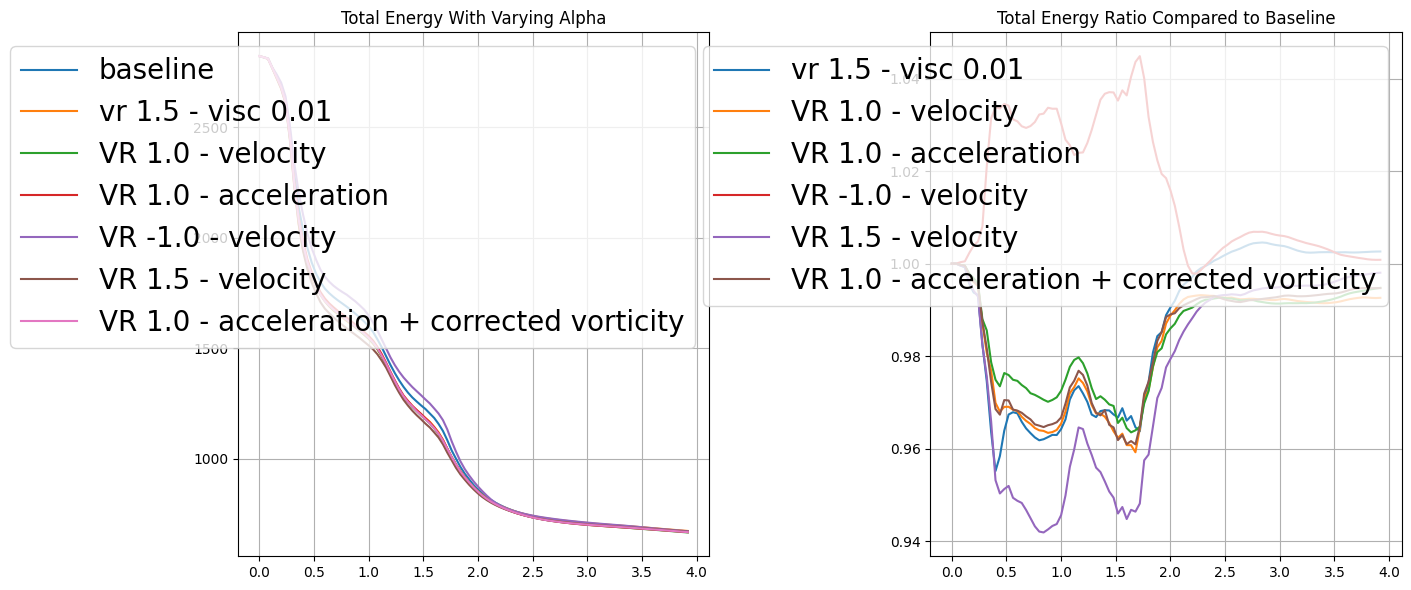

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 100
time = [i / 25 for i in range(99)]

for folder in ['baseline', 'vr 1.5 - visc 0.01', 'VR 1.0 - velocity', 'VR 1.0 - acceleration','VR -1.0 - velocity', 'VR 1.5 - velocity', 'VR 1.0 - acceleration + corrected vorticity']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum(mass * (norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     ax1.plot(kin_energy, label="{}".format(folder))
    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy With Varying Alpha")


kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum(mass *(norm(velocity, axis=1)**2) / 2)
            kin_energy_baseline.append(aux_kin_energy)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

for folder in ['vr 1.5 - visc 0.01','VR 1.0 - velocity', 'VR 1.0 - acceleration','VR -1.0 - velocity', 'VR 1.5 - velocity', 'VR 1.0 - acceleration + corrected vorticity']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy/kin_energy_baseline[i-begin])
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax2.plot(time, total_energy, label="{}".format(folder))
#     ax2.plot(time, kin_energy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()    # neat spacing
plt.show()

In [64]:
scene = 'DamBreakModelWithWall'
folder_path = splishsplash_path + '/' + scene + '/visc_standard_005/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//DamBreakModelWithWall/visc_standard_005/
['VR 1.0 - velocity', 'VR 1.5 - velocity', 'baseline']


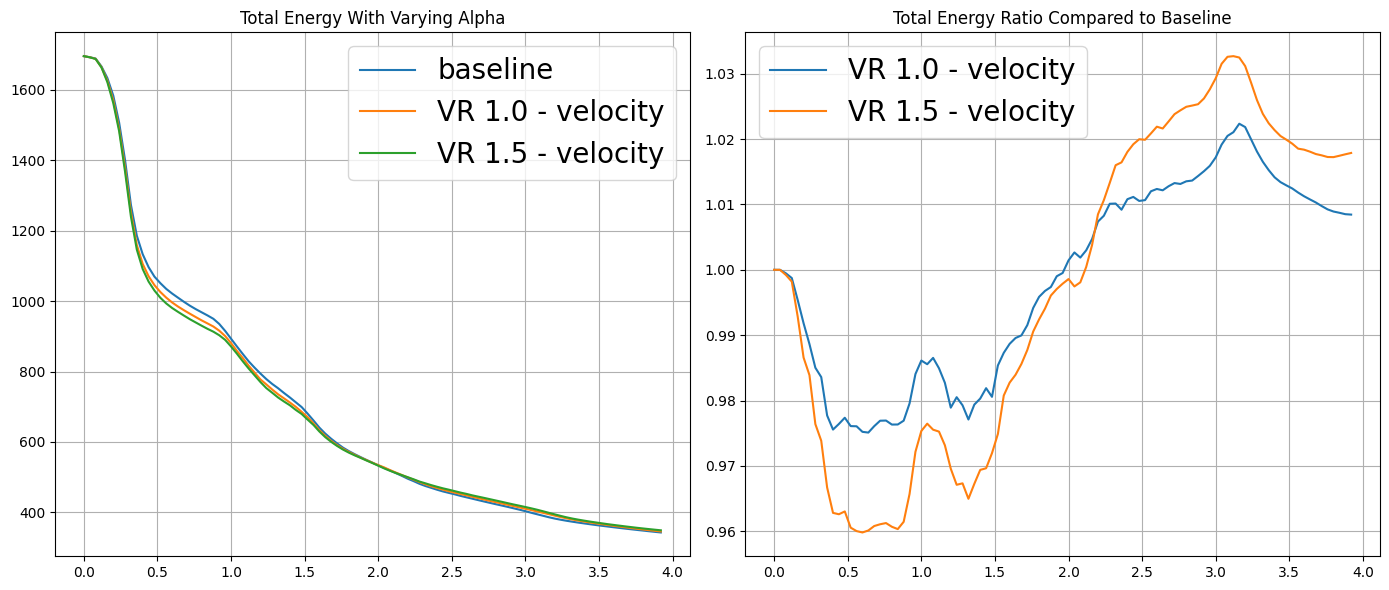

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 100
time = [i / 25 for i in range(99)]

for folder in ['baseline', 'VR 1.0 - velocity', 'VR 1.5 - velocity']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum(mass * (norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     ax1.plot(kin_energy, label="{}".format(folder))
    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy With Varying Alpha")


kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum(mass *(norm(velocity, axis=1)**2) / 2)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

for folder in ['VR 1.0 - velocity', 'VR 1.5 - velocity']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax2.plot(time, total_energy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()    # neat spacing
plt.show()

In [30]:
## distribution of velocities - not relevant
# import os
# import numpy as np
# import meshio
# import matplotlib.pyplot as plt
# from numpy.linalg import norm
# from scipy.stats import gaussian_kde

# plt.figure(figsize=(8, 6))

# begin = 25
# end = 26

# # Collect all data to find global velocity range
# all_vel = []

# for folder in ['baseline', 'VR 1.0 - velocity', 'VR 1.5 - velocity']:
#     full_path = folder_path + folder + '/'
#     total = 0
#     for i in range(begin, end):
#         file = f'ParticleData_Fluid_{i}.vtk'
#         mesh = meshio.read(full_path + file)
#         velocity = mesh.point_data['velocity']
#         vel = norm(velocity, axis=1)   # <-- use velocity magnitude (not squared)
#         total += np.sum(vel)
#         all_vel.extend(vel)
        
#     print(folder)
#     print(total)
        

# # Define shared range for smooth plots
# x_vals = np.linspace(np.min(all_vel), np.max(all_vel), 500)

# # Plot smooth distributions
# for folder in ['baseline', 'VR 1.0 - velocity', 'VR 1.5 - velocity']:
#     full_path = folder_path + folder + '/'
#     vel_all = []

#     for i in range(begin, end):
#         file = f'ParticleData_Fluid_{i}.vtk'
#         mesh = meshio.read(full_path + file)
#         velocity = mesh.point_data['velocity']
#         vel = norm(velocity, axis=1)
#         vel_all.extend(vel)

#     # KDE: smooth probability density estimate
#     kde = gaussian_kde(vel_all, bw_method=0.2)  # you can tune bw_method for smoothness
#     plt.plot(x_vals, kde(x_vals), label=folder, linewidth=2)

# # Format plot
# plt.legend(fontsize=14)
# plt.grid(True)
# plt.xlabel("Velocity magnitude")
# plt.ylabel("Probability density")
# plt.title("Velocity Distribution Comparison (Smoothed)")
# plt.tight_layout()
# plt.show()


## Linear X Rotational Field

Linear - no vorticity - no correction
2 Particles same direction different velocities
2 particles opposite velocity

In [39]:
scene = 'shearflow'

folder_path = splishsplash_path + '/' + scene + '/viscfluid0.01/'

print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//shearflow/viscfluid0.01/
['alpha 1.0 visc 0.01', 'alpha 1.0 visc 0.0', 'alpha 1.5 visc 0.01', 'alpha 1.5 visc 0.0', 'baseline']


C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in float_scalars


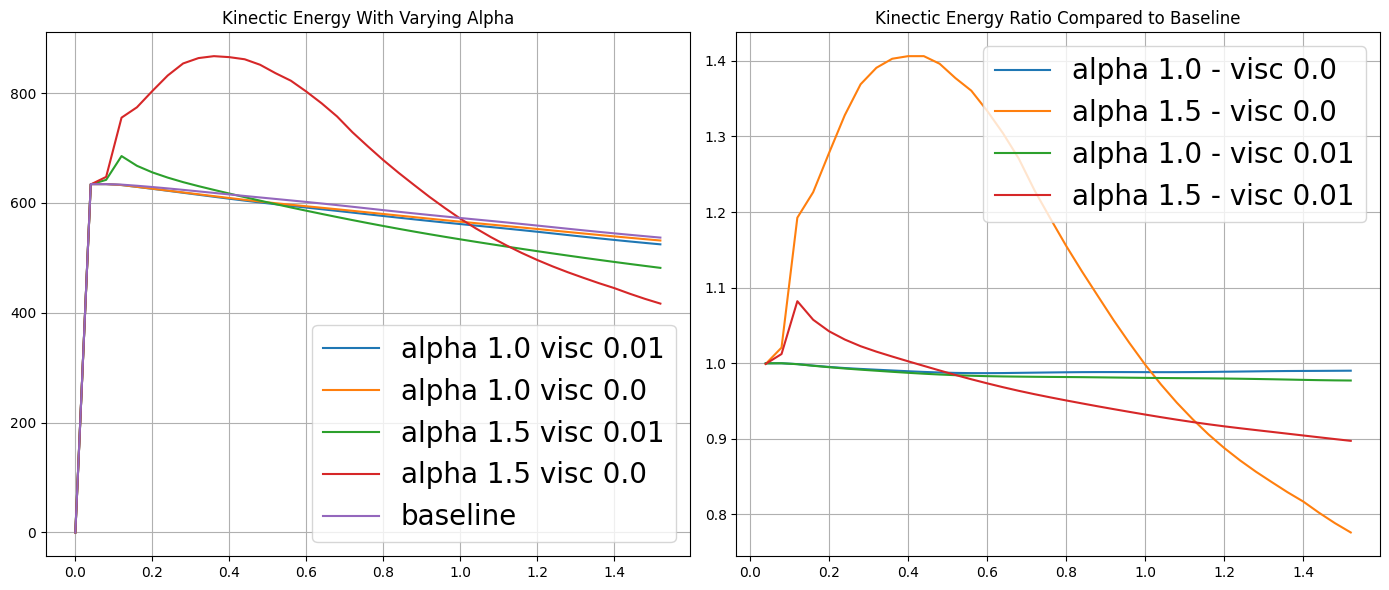

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 40
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
#             aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
#             ls_total_energy.append((aux_pot_energy + aux_kin_energy))
            ls_total_energy.append((aux_kin_energy))
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
    ax1.plot(time, ls_total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Kinectic Energy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 visc 0.0'], total_energy['baseline'])], label="alpha 1.0 - visc 0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.5 visc 0.0'], total_energy['baseline'])], label="alpha 1.5 - visc 0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 visc 0.01'], total_energy['baseline'])], label="alpha 1.0 - visc 0.01")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.5 visc 0.01'], total_energy['baseline'])], label="alpha 1.5 - visc 0.01")

ax2.legend(fontsize=20)
ax2.grid(True)
ax2.set_title("Kinectic Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


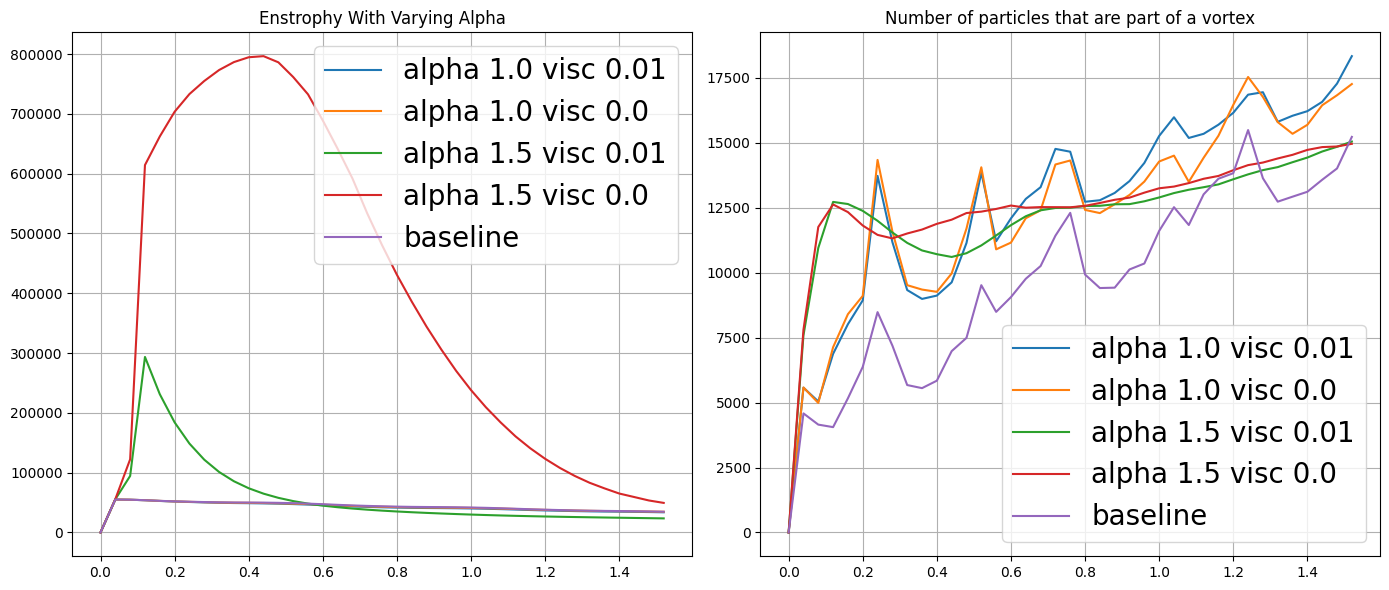

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 40
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    is_vortex = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
            
            is_vortex.append(np.count_nonzero(mesh.point_data['m_is_vortex']))
        else:
            enstrophy.append(0)
            is_vortex.append(0)

    ax1.plot(time, enstrophy, label="{}".format(folder))
    ax2.plot(time, is_vortex, label="{}".format(folder))

ax1.legend(fontsize=20)
ax1.grid(True)
ax1.set_title("Enstrophy With Varying Alpha")

ax2.legend(fontsize=20)
ax2.grid(True)
ax2.set_title("Number of particles that are part of a vortex")

plt.tight_layout()

plt.show()

In [42]:
scene = 'rotationalflow'

folder_path = splishsplash_path + '/' + scene + '/viscfluid0.01/'

print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//rotationalflow/viscfluid0.01/
['baseline', 'alpha 1.0 visc 0.0', 'alpha 1.3 visc 0.0', 'alpha 1.0 visc 0.01', 'alpha 1.3 visc 0.01']


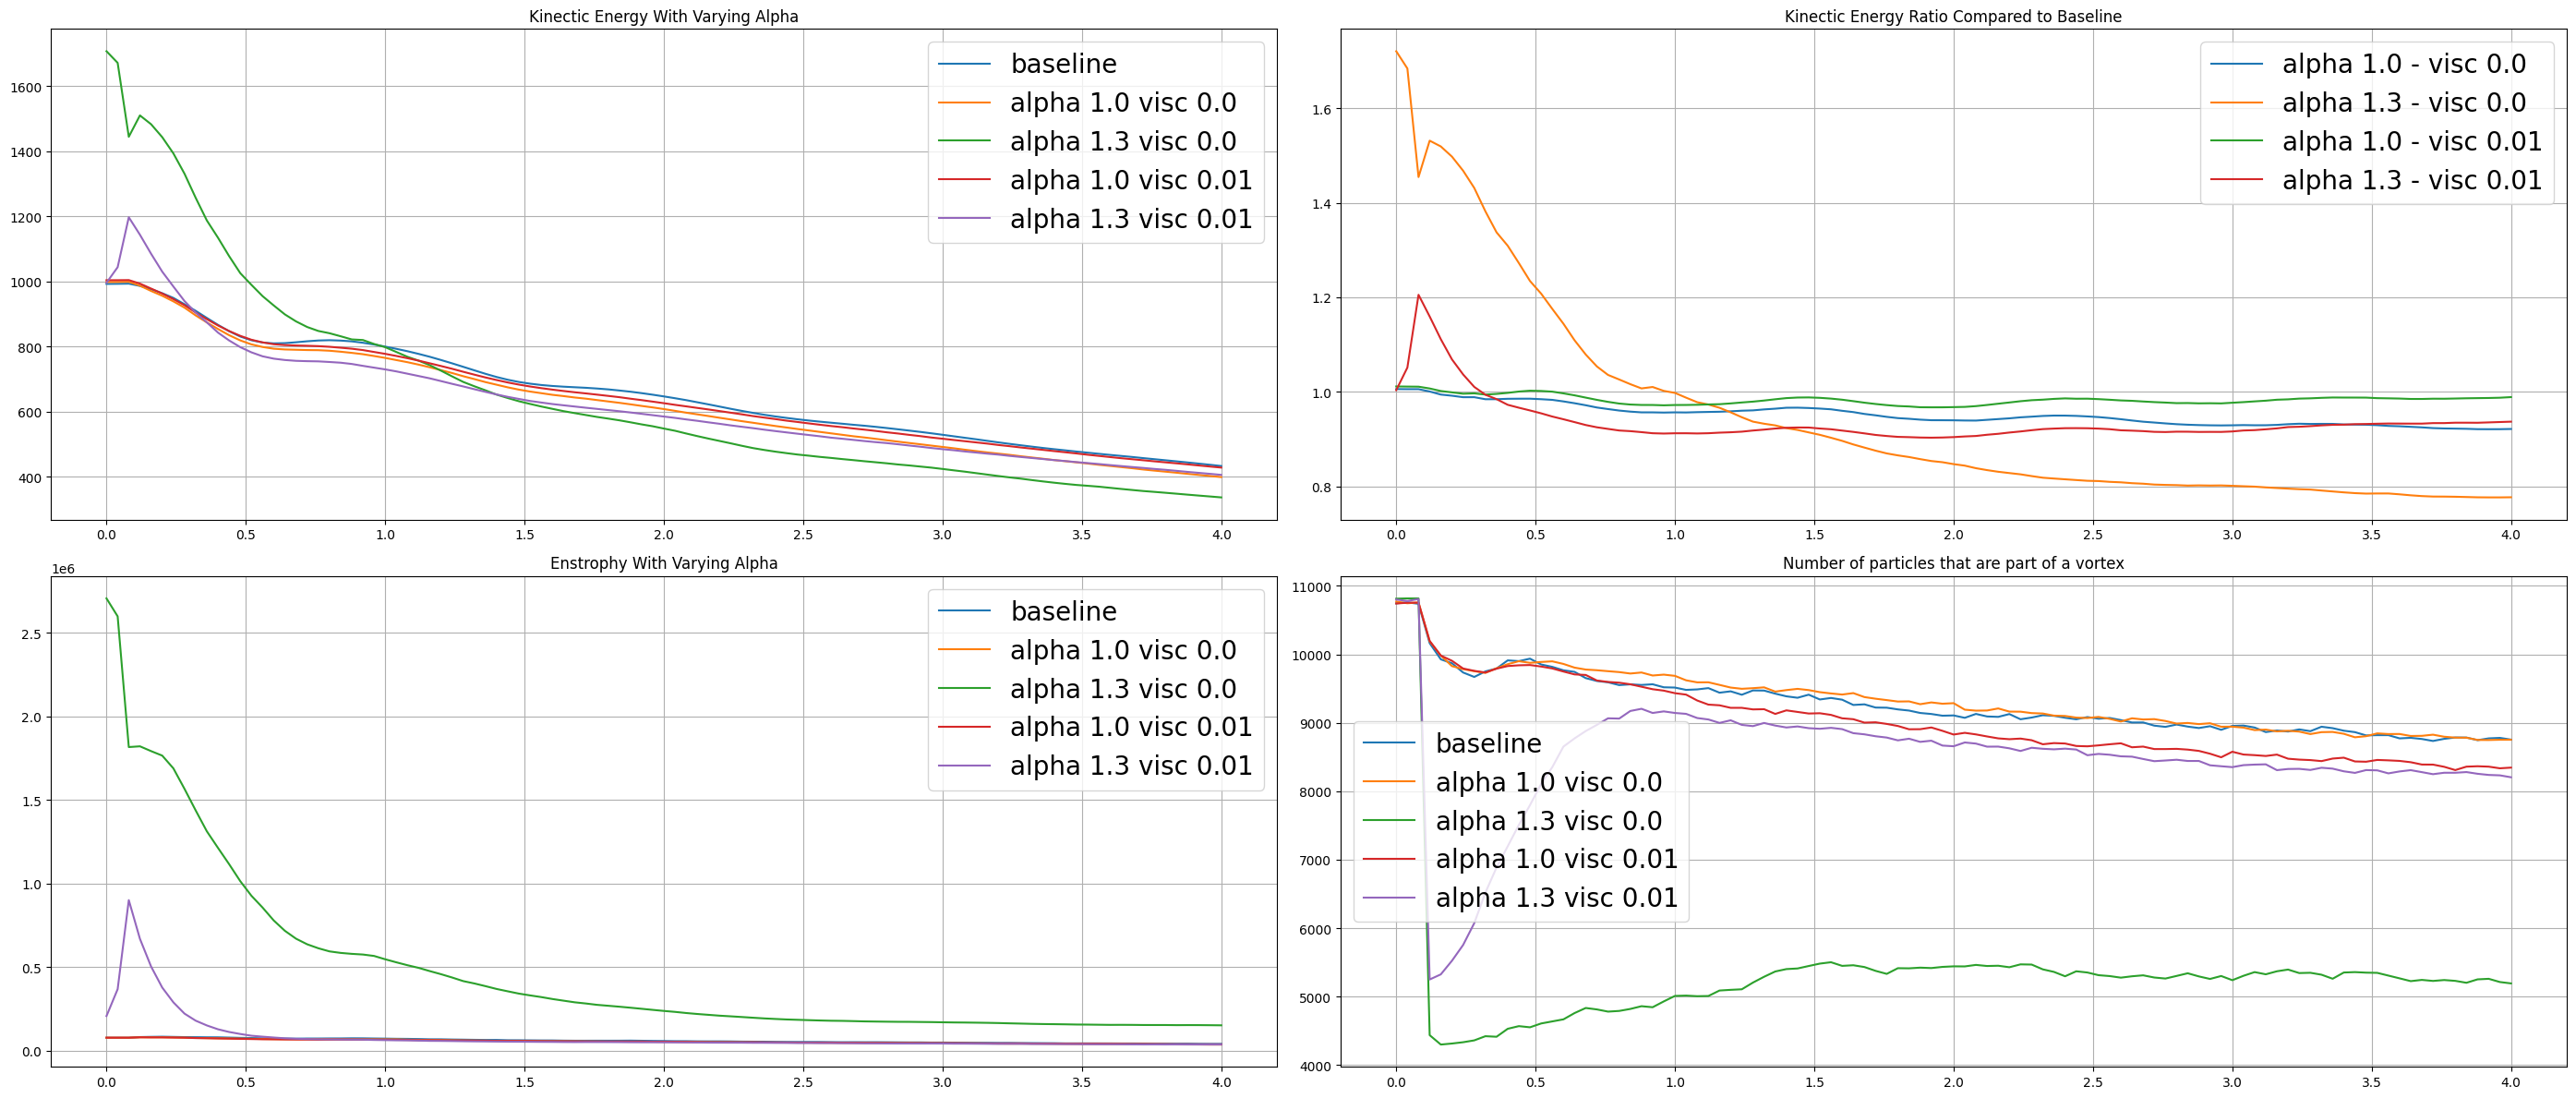

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(28, 12)) 
ax1, ax2, ax3, ax4 = axes.flatten()

begin = 74
end = 7*25
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    is_vortex = []
    
    ls_total_energy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
#             aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
#             ls_total_energy.append((aux_pot_energy + aux_kin_energy))
            ls_total_energy.append((aux_kin_energy))
    
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
            
            is_vortex.append(np.count_nonzero(mesh.point_data['m_is_vortex']))
#         else:
#             ls_total_energy.append(0)
            
    ax3.plot(time, enstrophy, label="{}".format(folder))
    ax4.plot(time, is_vortex, label="{}".format(folder))
    total_energy[folder] = ls_total_energy
    ax1.plot(time, ls_total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Kinectic Energy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 visc 0.0'], total_energy['baseline'])], label="alpha 1.0 - visc 0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.3 visc 0.0'], total_energy['baseline'])], label="alpha 1.3 - visc 0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 visc 0.01'], total_energy['baseline'])], label="alpha 1.0 - visc 0.01")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.3 visc 0.01'], total_energy['baseline'])], label="alpha 1.3 - visc 0.01")

ax2.legend(fontsize=20)
ax2.grid(True)
ax2.set_title("Kinectic Energy Ratio Compared to Baseline")

ax3.legend(fontsize=20)
ax3.grid(True)
ax3.set_title("Enstrophy With Varying Alpha")

ax4.legend(fontsize=20)
ax4.grid(True)
ax4.set_title("Number of particles that are part of a vortex")

plt.tight_layout()

plt.show()

## Understanding the Effects of the Stretching Term

In [66]:
scene = 'DamBreakModel'
folder_path = splishsplash_path + '/' + scene + '/inviscid with xsph 0.001/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//DamBreakModel/inviscid with xsph 0.001/
['VR 1.0 - velocity', 'VR 1.5 - velocity', 'baseline']


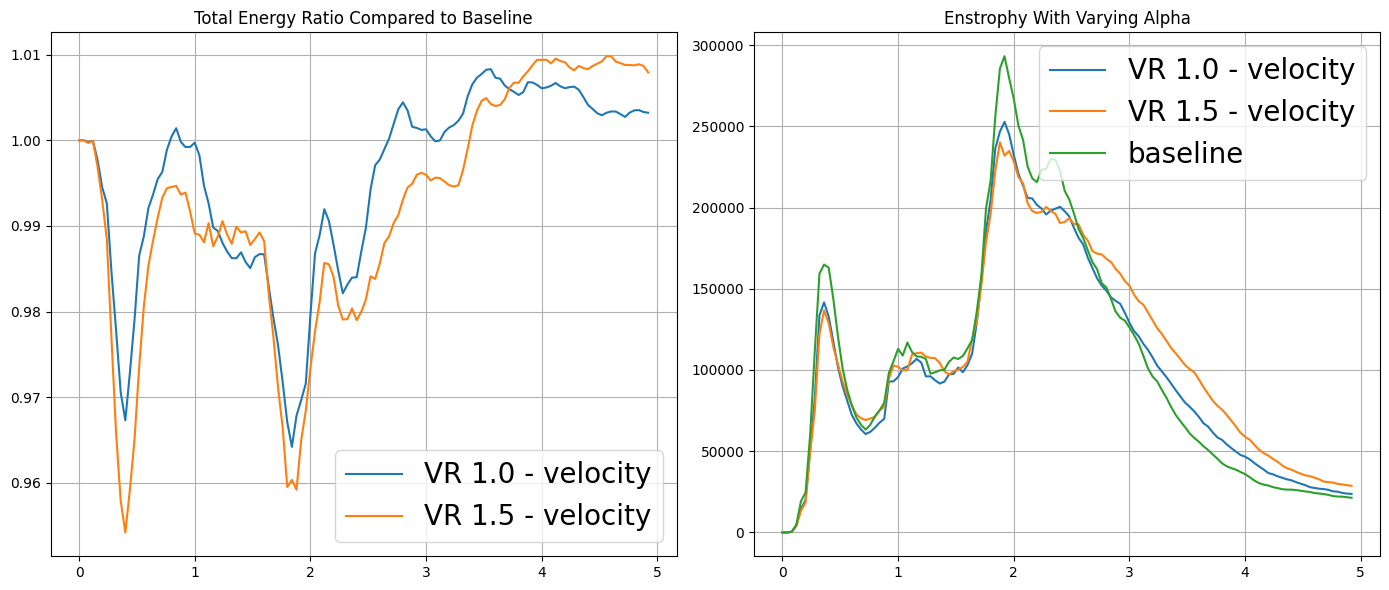

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 125
time = [i / 25 for i in range(124)]

kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

for folder in ['VR 1.0 - velocity', 'VR 1.5 - velocity']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy Ratio Compared to Baseline")


for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax2.plot(time, enstrophy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Enstrophy With Varying Alpha")


plt.tight_layout()    # neat spacing

plt.show()

In [108]:
scene = 'DamBreakModelWithWall'
# fluid 0.02
# visc no method 0.0 - only stretching term working
# different values of alpha
folder_path = splishsplash_path + '/' + scene + '/visc_standard_002_fluid_stretching_term/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//DamBreakModelWithWall/visc_standard_002_fluid_stretching_term/
['baseline', 'alpha 1.0', 'alpha 1.5']


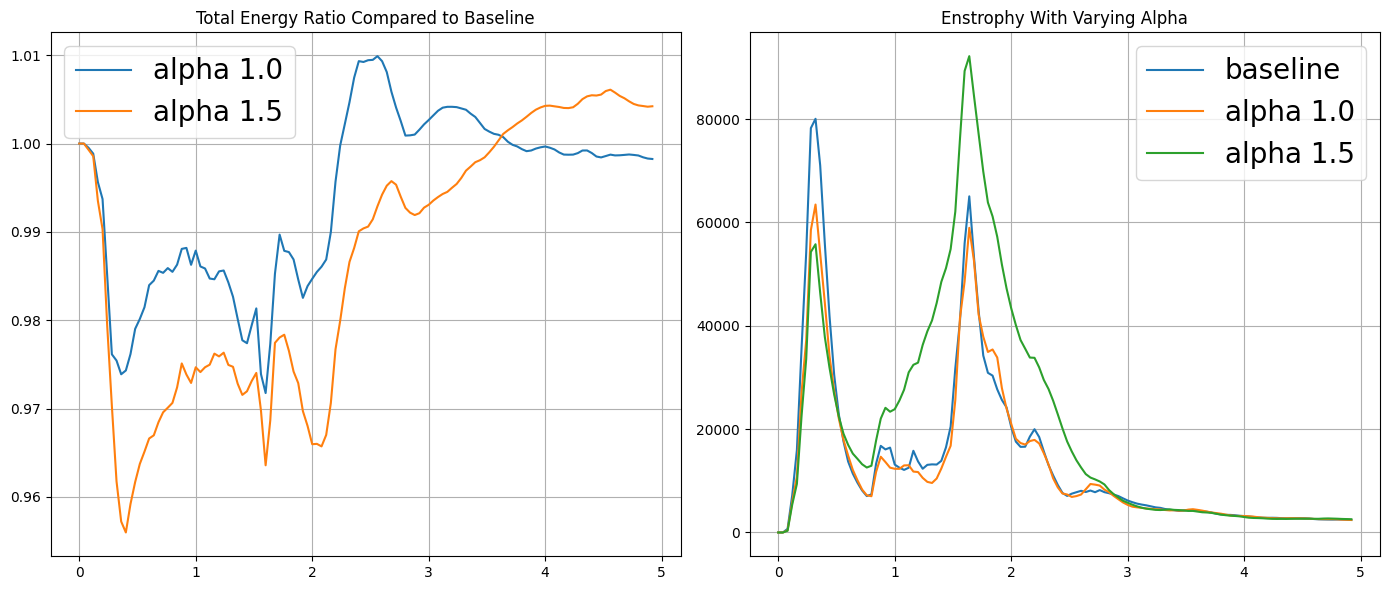

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 125
time = [i / 25 for i in range(124)]

kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

for folder in ['alpha 1.0', 'alpha 1.5']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy Ratio Compared to Baseline")


for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax2.plot(time, enstrophy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Enstrophy With Varying Alpha")


plt.tight_layout()    # neat spacing

plt.show()

In [113]:
scene = 'DamBreakModelWithWall'
folder_path = splishsplash_path + '/' + scene + '/inviscid with xsph 0.001_visc_with_method/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//DamBreakModelWithWall/inviscid with xsph 0.001_visc_with_method/
['baseline', 'VR 1.5 - velocity', 'VR 1.0 - velocity']


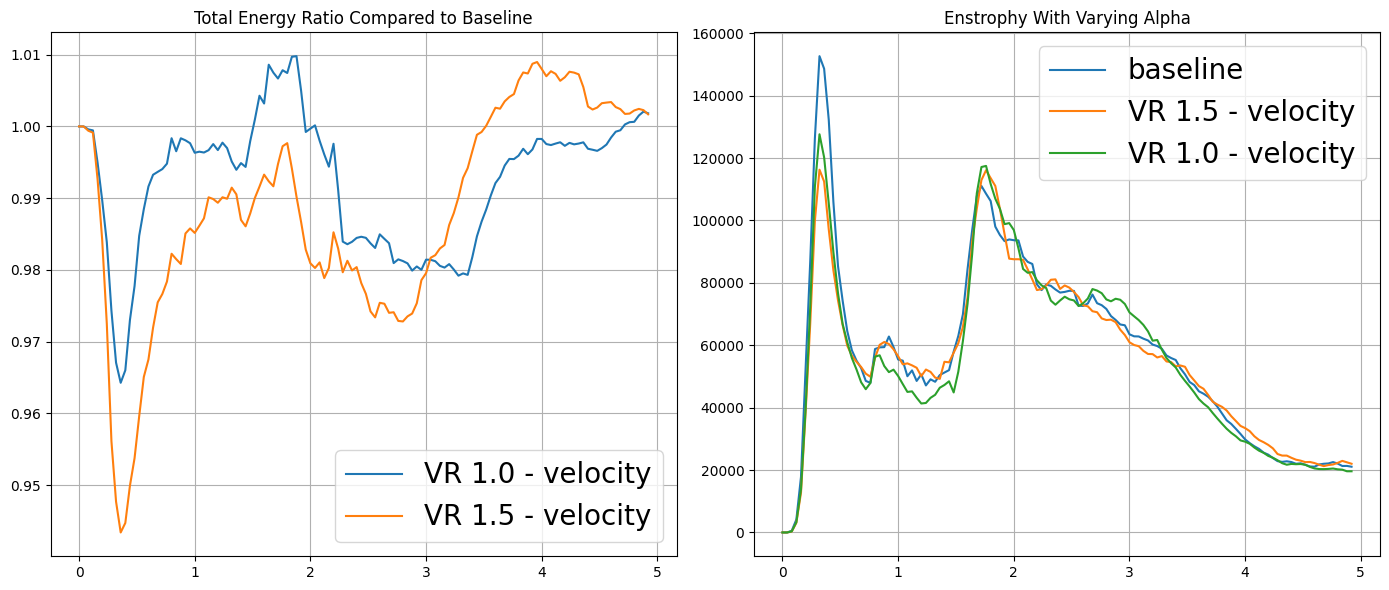

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 125
time = [i / 25 for i in range(end - begin)]

kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

for folder in ['VR 1.0 - velocity', 'VR 1.5 - velocity']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy Ratio Compared to Baseline")


for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax2.plot(time, enstrophy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Enstrophy With Varying Alpha")


plt.tight_layout()    # neat spacing

plt.show()

## Understanding the Effects of the Diffusion Term

In [ ]:
# For a Dam Break and TGV - for a fluid with Visc 0.02 and for alpha = 1.0. We see how much the vorticity 
# changes when varying the viscosity coefficient on the method
# Values for v_v on the method: 0.01, 0.03, 0.05

In [93]:
scene = 'DamBreakModelWithWall'

folder_path = splishsplash_path + '/' + scene + '/testing_difusion_term_alpha 1.0/visc_dettached_from_method/'

print(folder_path)

folders = os.listdir(folder_path)
print(folders)

folders.remove('baseline')
print(folders)

D:/gabi//DamBreakModelWithWall/testing_difusion_term_alpha 1.0/visc_dettached_from_method/
['0.05', '0.02', '0.01', 'baseline', '0.00']
['0.05', '0.02', '0.01', '0.00']


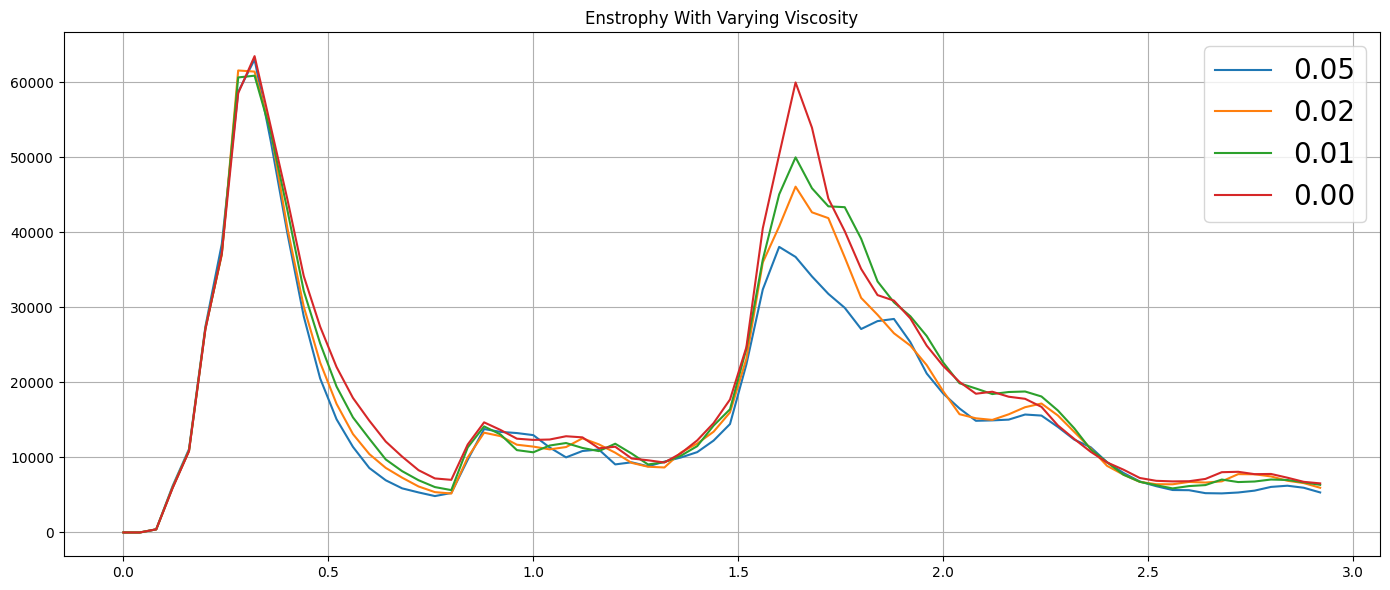

In [98]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1 = axes 

begin = 1
end = 75
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax1.plot(time, enstrophy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Enstrophy With Varying Viscosity")

plt.tight_layout()    # neat spacing

plt.show()

In [60]:
scene = 'DamBreakModelWithWallMoreFluid'

folder_path = splishsplash_path + '/' + scene + '/visc fluid 0.02/'

print(folder_path)

folders = os.listdir(folder_path)
print(folders)


D:/gabi//DamBreakModelWithWallMoreFluid/visc fluid 0.02/
['baseline', '0.05']


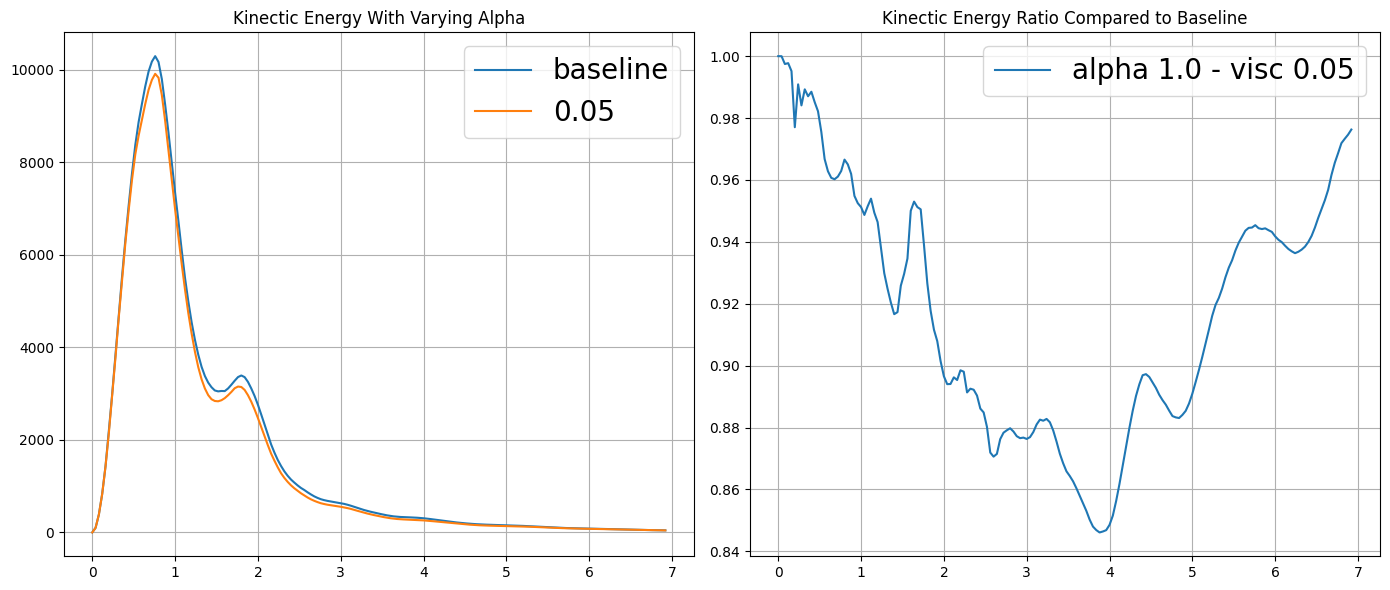

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 175
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
#             aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
#             ls_total_energy.append((aux_pot_energy + aux_kin_energy))
            ls_total_energy.append((aux_kin_energy))
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
    ax1.plot(time, ls_total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Kinectic Energy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['0.05'], total_energy['baseline'])], label="alpha 1.0 - visc 0.05")

ax2.legend(fontsize=20)
ax2.grid(True)
ax2.set_title("Kinectic Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


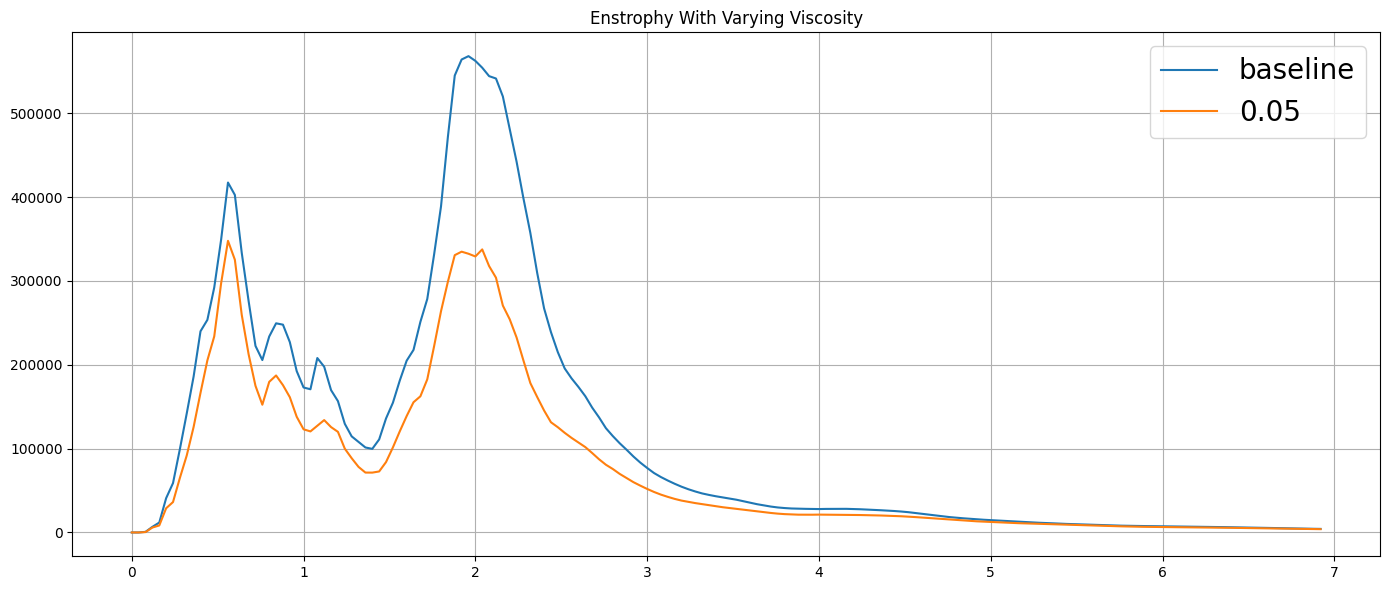

In [63]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1 = axes 

begin = 1
end = 175
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax1.plot(time, enstrophy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Enstrophy With Varying Viscosity")

plt.tight_layout()    # neat spacing

plt.show()

In [100]:
scene = 'tgv3dnogravity'

folder_path = splishsplash_path + '/' + scene + '/testing_diffusion_term_alpha_1/fluid_visc_002/'

print(folder_path)

folders = os.listdir(folder_path)
print(folders)

folders.remove('baseline')
print(folders)

D:/gabi//tgv3dnogravity/testing_diffusion_term_alpha_1/fluid_visc_002/
['0.02', '0.05', 'baseline', '0.00']
['0.02', '0.05', '0.00']


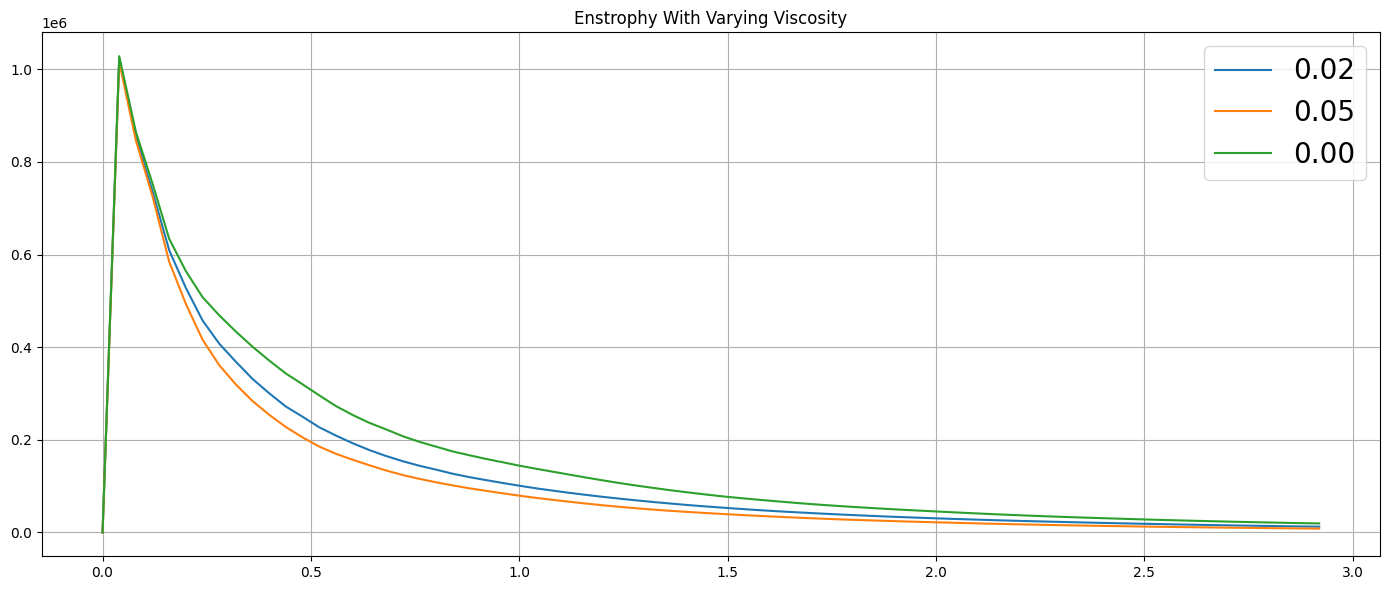

In [101]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1 = axes 

begin = 1
end = 75
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax1.plot(time, enstrophy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Enstrophy With Varying Viscosity")

plt.tight_layout()    # neat spacing

plt.show()

In [ ]:
# fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
# ax1 = axes 

# begin = 4
# end = 175
# time = [i / 25 for i in range(end - begin)]

# total_energy = {}
    
# for folder in folders:
#     full_path = folder_path + folder + '/'
#     files = os.listdir(full_path)
    
#     ls_total_energy = []
#     for i in range(begin,end):
#         file = 'ParticleData_Fluid_{}.vtk'.format(i)

#         mesh = meshio.read(full_path + file)
#         positions = mesh.points

#         h = mesh.points[:,1]
#         velocity = mesh.point_data['velocity']
#         mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

#         number_particles = len(h)
#         if number_particles > 0:
#             aux_pot_energy = np.sum(mass * h * 9.81)            
#             aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
#             ls_total_energy.append((aux_pot_energy + aux_kin_energy))
#         else:
#             ls_total_energy.append(0)
            
#     total_energy[folder] = ls_total_energy

# ax1.plot(time, [x / y for x, y in zip(total_energy['0.05'], total_energy['0.00'])], label="0.05")
# ax1.plot(time, [x / y for x, y in zip(total_energy['0.02'], total_energy['0.00'])], label="0.02")
# # ax1.plot(time, [x / y for x, y in zip(total_energy['0.01'], total_energy['0.00'])], label="0.01")
# # ax1.plot(time, [x / y for x, y in zip(total_energy['0.00'], total_energy['baseline'])], label="0.00")
# # ax1.plot(time, [x / y for x, y in zip(total_energy['inviscid'], total_energy['baseline inviscid'])], label="inviscid")


# ax1.legend(fontsize=20)          # show the labels
# ax1.grid(True)        # optional grid
# ax1.set_title("For alpha 1.0, Total Energy Ratio Compared to Baseline with Vayring Viscosity Coefficient")


# for folder in folders:
#     full_path = folder_path + folder + '/'
#     files = os.listdir(full_path)
    
#     enstrophy = []
    
#     for i in range(begin,end):
#         file = 'ParticleData_Fluid_{}.vtk'.format(i)

#         mesh = meshio.read(full_path + file)
#         positions = mesh.points

#         vorticity = mesh.point_data['vorticity_corrected_end']
#         mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

#         number_particles = len(h)
#         if number_particles > 0:           
#             aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
#             enstrophy.append(aux_kin_ens)
#         else:
#             enstrophy.append(0)

#     ax1.plot(time, enstrophy, label="{}".format(folder))

# ax1.legend(fontsize=20)          # show the labels
# ax1.grid(True)        # optional grid
# ax1.set_title("Enstrophy With Varying Viscosity")

# plt.tight_layout()    # neat spacing

# plt.show()

## Influence of System Size and Initial Vorticity Level on Vorticity Dynamics  

In [135]:
scene = 'EmitterLarge'
folder_path = splishsplash_path + '/' + scene + '/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//EmitterLarge/
['VR 1.0', 'baseline']


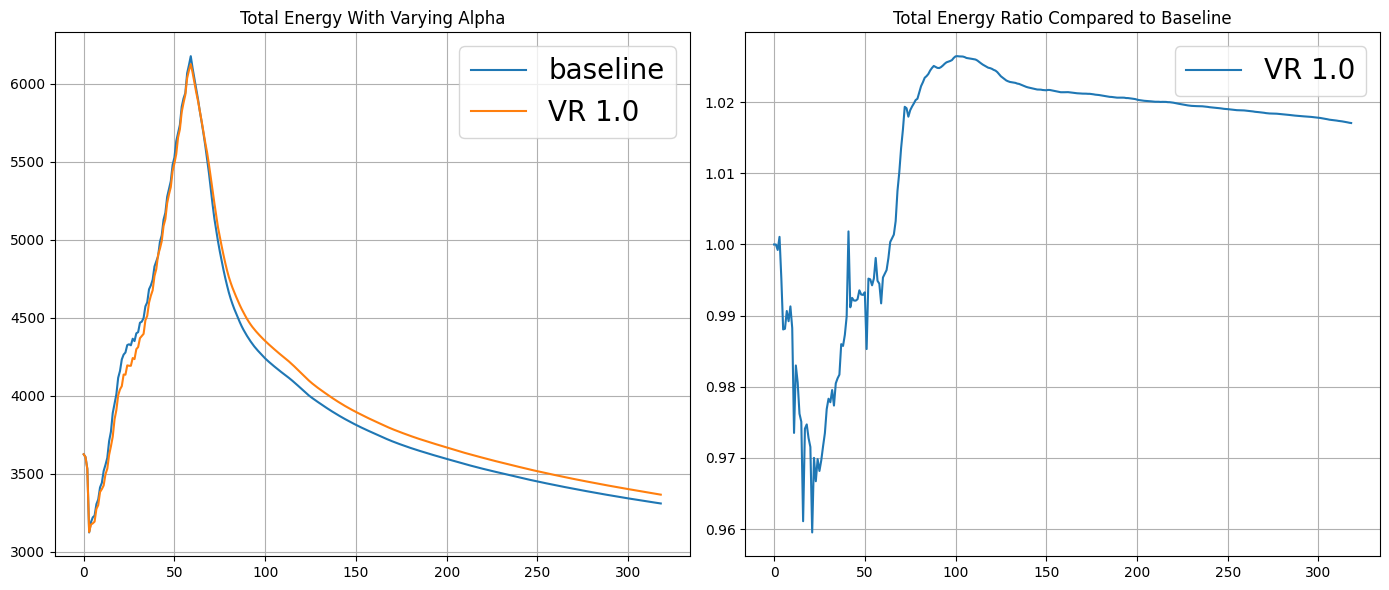

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 320
fps=1
time = [i / fps for i in range(end - begin)]

# for folder in folders:
for folder in ['baseline','VR 1.0']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy With Varying Alpha")


kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

# for folder in folders:
for folder in ['VR 1.0']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax2.plot(time, total_energy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()    # neat spacing
plt.show()

## Visual Evaluation of the Turbulence Details

## Testing Different Advection-Projection Methods

In [91]:
scene = 'DamBreakModel'
folder_path = splishsplash_path + '/' + scene
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//DamBreakModel
['dfsph_inviscid_advected_velocity_for_derivative', 'dfsph_inviscid_derivative_beginning', 'dfsph_visc_forces', 'dfsph_visc_standard_005_advected_velocity_for_derivative', 'dfsph_visc_standard_005_derivative_beginning', 'iisph_visc_standard_005', 'inviscid', 'log', 'pcisph_visc_standard_005', 'visc_standard_005', 'inviscid with xsph 0.001', 'testing_difusion_term_alpha 1.0']


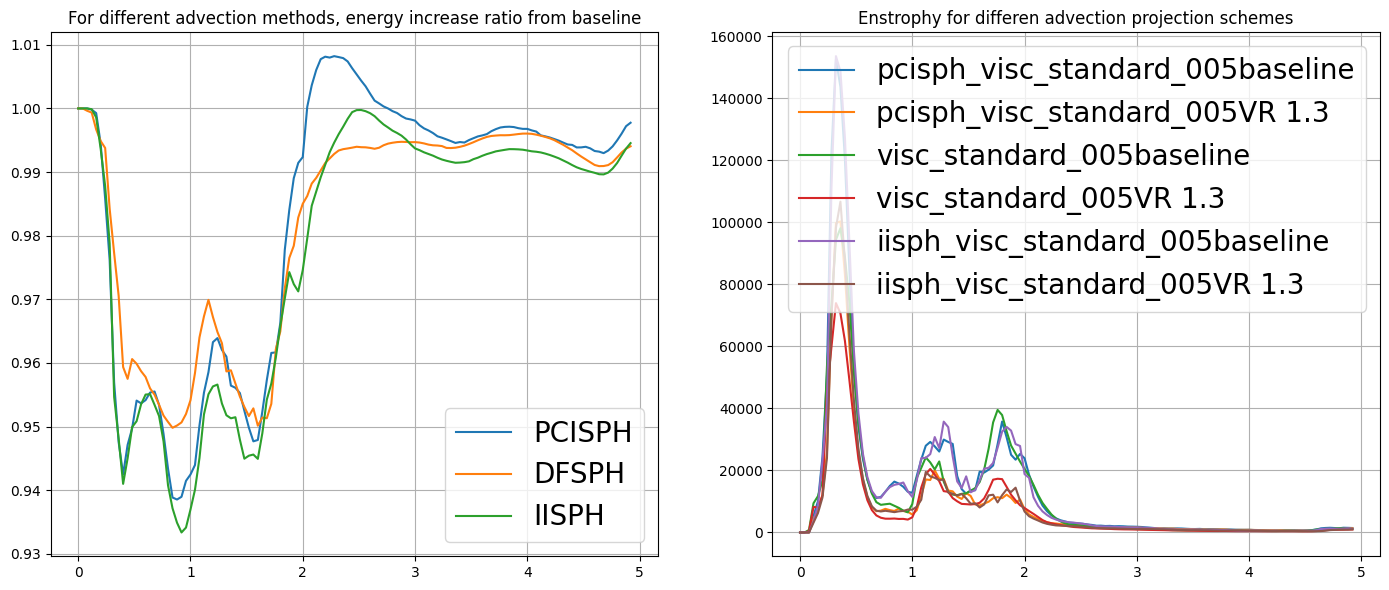

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 125
time = [i / 25 for i in range(124)]

total_energy = {}
    
for folder in ['pcisph_visc_standard_005', 'visc_standard_005', 'iisph_visc_standard_005']:
    main_folder_path = folder_path + '/' + folder + '/'
    for subfolder in ['baseline', 'VR 1.3']:
        child_folder_path = main_folder_path + subfolder + '/'
        files = os.listdir(full_path)

        ls_total_energy = []
        for i in range(begin,end):
            file = 'ParticleData_Fluid_{}.vtk'.format(i)

            mesh = meshio.read(child_folder_path + file)
            positions = mesh.points

            h = mesh.points[:,1]
            velocity = mesh.point_data['velocity']
            mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

            number_particles = len(h)
            if number_particles > 0:
                aux_pot_energy = np.sum(mass * h * 9.81)            
                aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
                ls_total_energy.append((aux_pot_energy + aux_kin_energy))
            else:
                ls_total_energy.append(0)

        total_energy[folder + '_' + subfolder] = ls_total_energy

# print(total_energy.keys())
ax1.plot(time, [x / y for x, y in zip(total_energy['pcisph_visc_standard_005_VR 1.3'], total_energy['pcisph_visc_standard_005_baseline'])], label="PCISPH")
ax1.plot(time, [x / y for x, y in zip(total_energy['visc_standard_005_VR 1.3'], total_energy['visc_standard_005_baseline'])], label="DFSPH")
ax1.plot(time, [x / y for x, y in zip(total_energy['iisph_visc_standard_005_VR 1.3'], total_energy['iisph_visc_standard_005_baseline'])], label="IISPH")

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("For different advection methods, energy increase ratio from baseline")



for folder in ['pcisph_visc_standard_005', 'visc_standard_005', 'iisph_visc_standard_005']:
    main_folder_path = folder_path + '/' + folder + '/'
    for subfolder in ['baseline', 'VR 1.3']:
        child_folder_path = main_folder_path + subfolder + '/'
        files = os.listdir(full_path)
    
        enstrophy = []

        for i in range(begin,end):
            file = 'ParticleData_Fluid_{}.vtk'.format(i)

            mesh = meshio.read(child_folder_path + file)
            positions = mesh.points

            vorticity = mesh.point_data['vorticity_corrected_end']
            mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

            number_particles = len(h)
            if number_particles > 0:           
                aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
                enstrophy.append(aux_kin_ens)
            else:
                enstrophy.append(0)

        ax2.plot(time, enstrophy, label="{}".format(folder + subfolder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Enstrophy for differen advection projection schemes")



plt.tight_layout()    # neat spacing

plt.show()

## Analysis on the Explicit Integration of Vorticity

In [116]:
scene = 'DamBreakModel'
folder_path = splishsplash_path + '/' + scene + '/visc_standard_005/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//DamBreakModel/visc_standard_005/
['baseline', 'mp_01', 'mp_04', 'vc_01', 'vc_05', 'vr -1.0', 'VR 1.0', 'VR 1.3', 'VR 1.5', 'VR 1.3 - deivative beginning', 'baseline -derivative beginning']


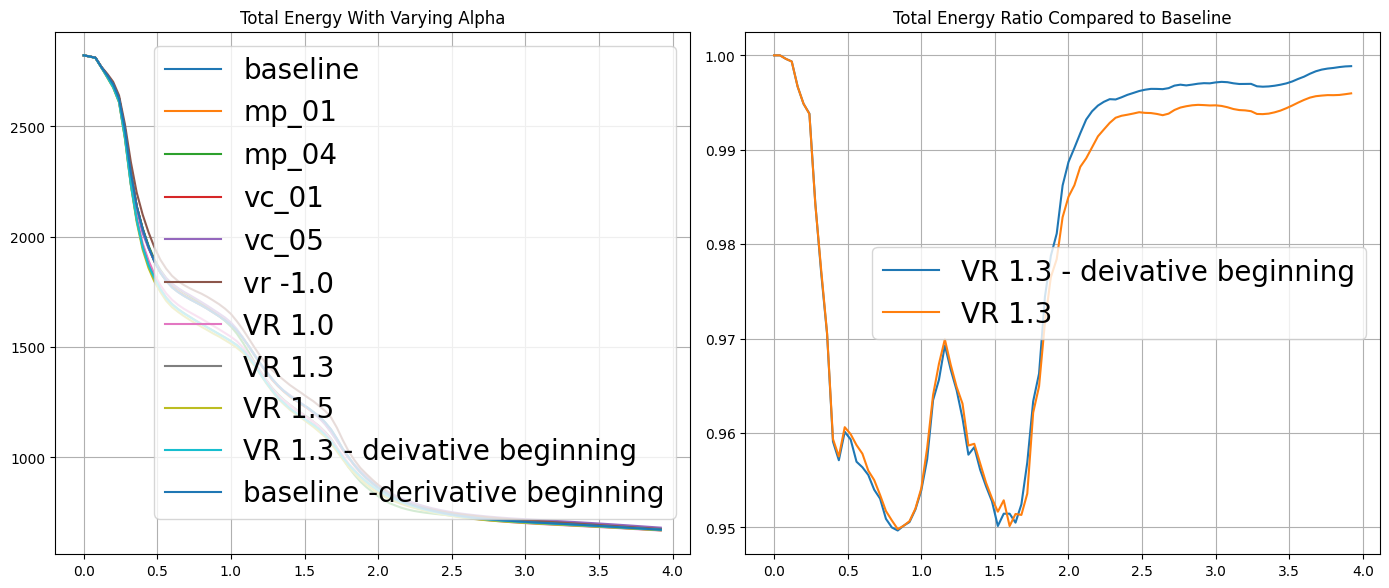

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 100
time = [i / 25 for i in range(99)]

for folder in folders:
# for folder in ['baseline','VR 1.0', 'VR 1.3',  'VR 1.5']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy With Varying Alpha")


kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

# for folder in folders:
for folder in ['VR 1.3 - deivative beginning','VR 1.3']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax2.plot(time, total_energy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()    # neat spacing
plt.show()

In [110]:
scene = 'Emitter/visc0.01/'
folder_path = splishsplash_path + '/' + scene
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//Emitter/visc0.01/
['baseline', 'vr1.0', 'vr 1.3 derivative beginning', 'baseline - derivative beginning', 'vr 1.0 derivative beginning']


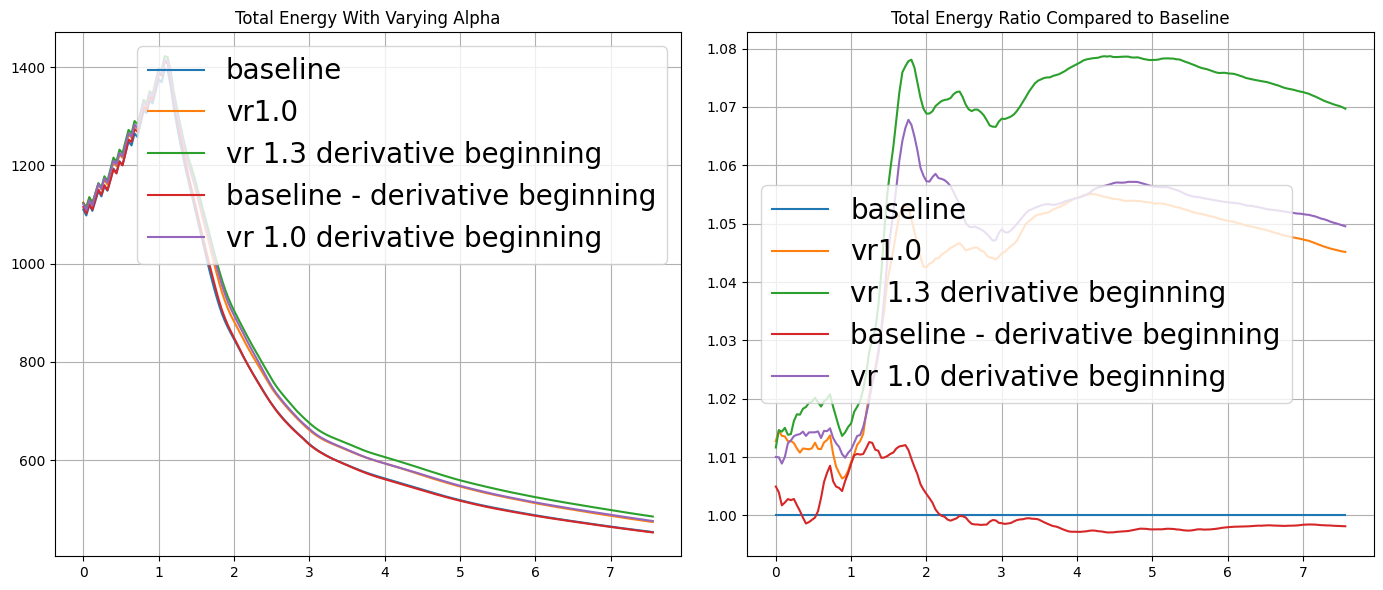

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 60
end = 250
time = [i / 25 for i in range(190)]

for folder in folders:
# for folder in ['baseline','VR 1.0', 'VR 1.3',  'VR 1.5']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy With Varying Alpha")


kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

# for folder in folders:
for folder in ['baseline', 'vr1.0', 'vr 1.3 derivative beginning', 'baseline - derivative beginning', 'vr 1.0 derivative beginning']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax2.plot(time, total_energy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()    # neat spacing
plt.show()

## Analysis of Energy Cascade

In [19]:
scene = 'TGV3DNoGravity'

folder_path = splishsplash_path + '/' + scene + '/viscfluid0.01/'

print(folder_path)

folders = os.listdir(folder_path)
print(folders)

# folders.remove('baseline')
print(folders)

D:/gabi//TGV3DNoGravity/viscfluid0.01/
['alpha 1.0 - visc 0.0', 'alpha 1.3 - visc 0.0', 'alpha 1.0 - visc 0.01', 'alpha 1.3 - visc 0.01', 'alpha 1.0 - visc 0.05', 'baseline', 'alpha 1.3 - visc 0.05']
['alpha 1.0 - visc 0.0', 'alpha 1.3 - visc 0.0', 'alpha 1.0 - visc 0.01', 'alpha 1.3 - visc 0.01', 'alpha 1.0 - visc 0.05', 'baseline', 'alpha 1.3 - visc 0.05']


C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:45: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:46: RuntimeWarning: invalid value encountered in float_scalars


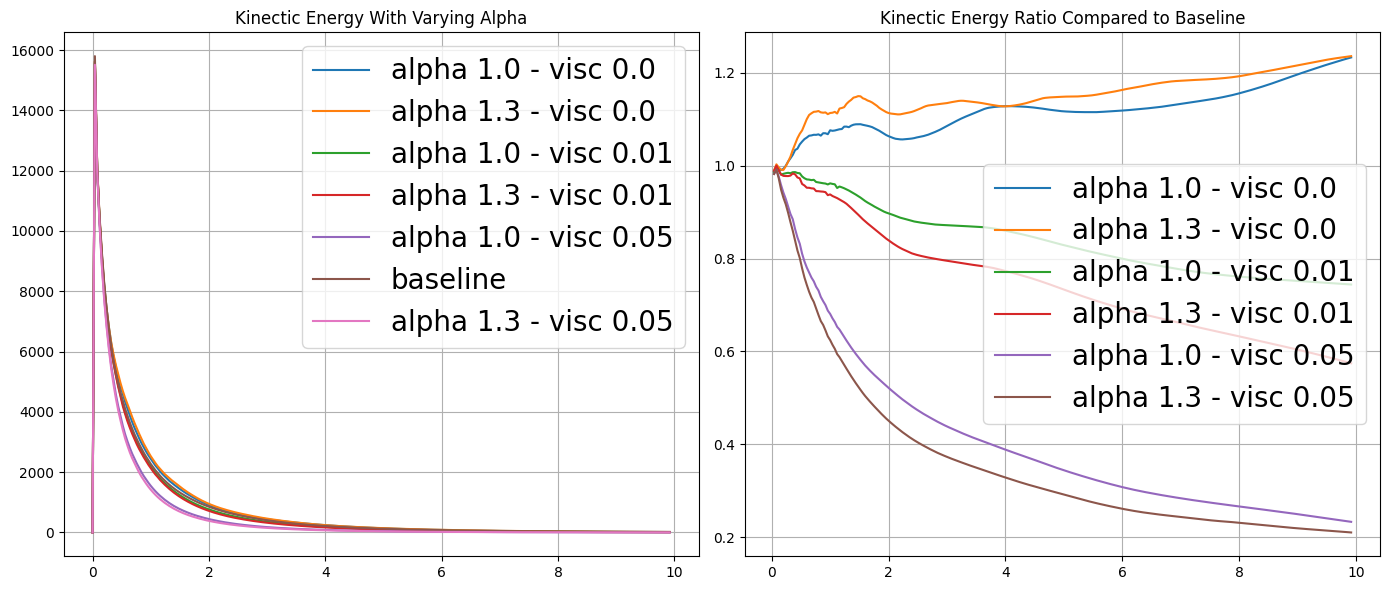

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
#             aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
#             ls_total_energy.append((aux_pot_energy + aux_kin_energy))
            ls_total_energy.append((aux_kin_energy))
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
    ax1.plot(time, ls_total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Kinectic Energy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 - visc 0.0'], total_energy['baseline'])], label="alpha 1.0 - visc 0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.3 - visc 0.0'], total_energy['baseline'])], label="alpha 1.3 - visc 0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 - visc 0.01'], total_energy['baseline'])], label="alpha 1.0 - visc 0.01")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.3 - visc 0.01'], total_energy['baseline'])], label="alpha 1.3 - visc 0.01")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 - visc 0.05'], total_energy['baseline'])], label="alpha 1.0 - visc 0.05")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.3 - visc 0.05'], total_energy['baseline'])], label="alpha 1.3 - visc 0.05")

ax2.legend(fontsize=20)
ax2.grid(True)
ax2.set_title("Kinectic Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


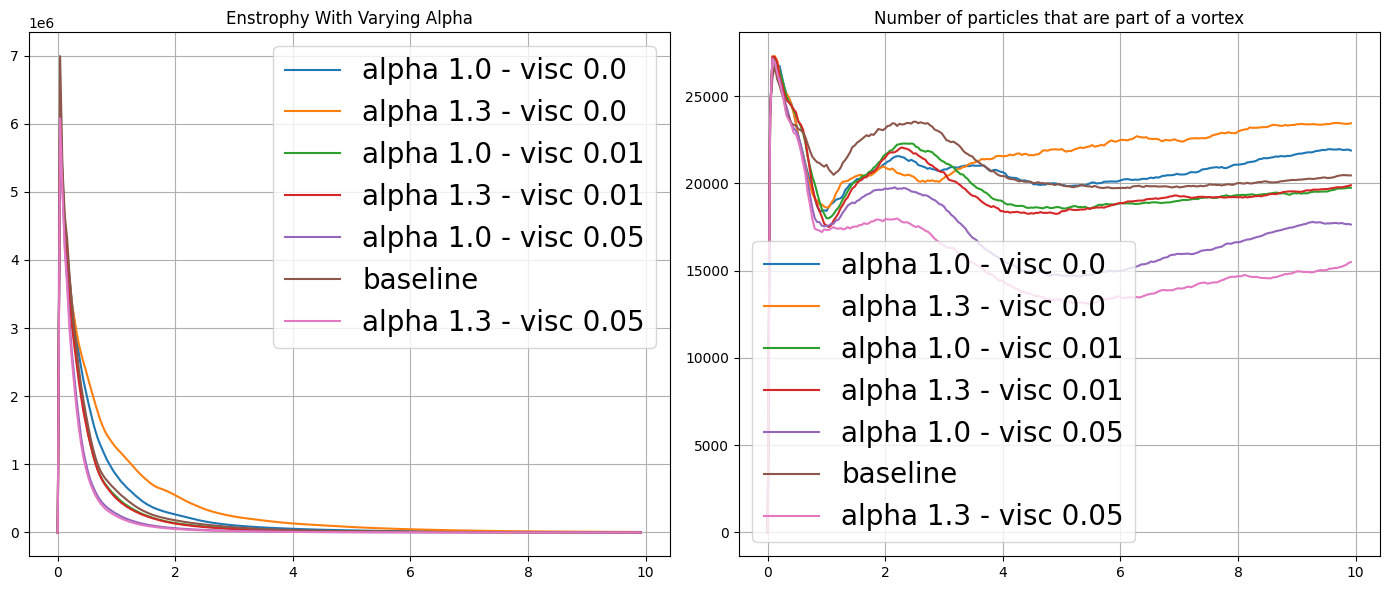

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    is_vortex = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
            
            is_vortex.append(np.count_nonzero(mesh.point_data['m_is_vortex']))
        else:
            enstrophy.append(0)
            is_vortex.append(0)

    ax1.plot(time, enstrophy, label="{}".format(folder))
    ax2.plot(time, is_vortex, label="{}".format(folder))

ax1.legend(fontsize=20)
ax1.grid(True)
ax1.set_title("Enstrophy With Varying Alpha")

ax2.legend(fontsize=20)
ax2.grid(True)
ax2.set_title("Number of particles that are part of a vortex")

plt.tight_layout()

plt.show()

In [35]:
scene = 'DamBreakModelWithWallMoreFluid'

folder_path = splishsplash_path + '/' + scene + '/visc fluid 0.01/'

print(folder_path)

folders = os.listdir(folder_path)

folders.remove('vr 1.0 - visc 0.01 (both) - curl symmetric - acceleration')
folders.remove('vr 0.0 - visc 0.01 (both) - curl symmetric - acceleration')
# print(folders)

folders = ['vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration'
           , 'vr 1.4 - visc 0.01 (both) - density_i on curls - acceleration'
           , 'vr 1.0 - visc 0.01 (both) - density_j all - acceleration'
           , 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'
           , 'vr 0.0 - visc 0.01 (both) - density_j all - acceleration']

print(folders)

D:/gabi//DamBreakModelWithWallMoreFluid/visc fluid 0.01/
['vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration', 'vr 1.4 - visc 0.01 (both) - density_i on curls - acceleration', 'vr 1.0 - visc 0.01 (both) - density_j all - acceleration', 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration', 'vr 0.0 - visc 0.01 (both) - density_j all - acceleration']


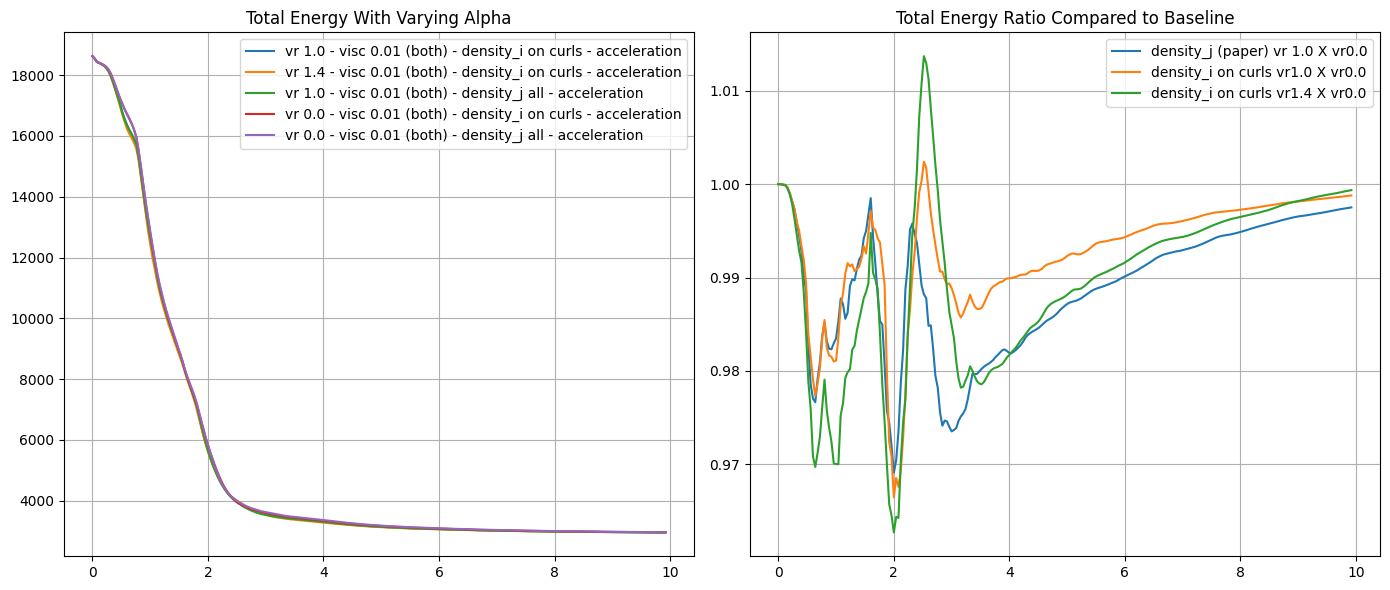

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_pot_energy + aux_kin_energy))
#             ls_total_energy.append((aux_kin_energy))
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
    ax1.plot(time, ls_total_energy, label="{}".format(folder))

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy With Varying Alpha")

# ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i - acceleration'])], label="density_i vr 1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_j all - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_j all - acceleration'])], label="density_j (paper) vr 1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="density_i on curls vr1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.4 - visc 0.01 (both) - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="density_i on curls vr1.4 X vr0.0")

# ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration'], total_energy['vr 1.0 - visc 0.01 (both) - density_i - acceleration'])], label="density_i on curls X density_i")
# ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i on curls and gradient- acceleration'], total_energy['vr 1.0 - visc 0.01 (both) - density_i - acceleration'])], label="density_i on curls and gradient")
# ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i cross and stream - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i cross and stream - acceleration'])], label="density_i on curls and stream vr1.0 X vr0.0")
# ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i cross and stream - acceleration'], total_energy['vr 1.0 - visc 0.01 (both) - density_i - acceleration'])], label="density_i on curls and stream X density_i")

# ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i on curls and diff_lap - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i - acceleration'])], label="density_i on curls + lap vr 1.0 X vr 0.0")


ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


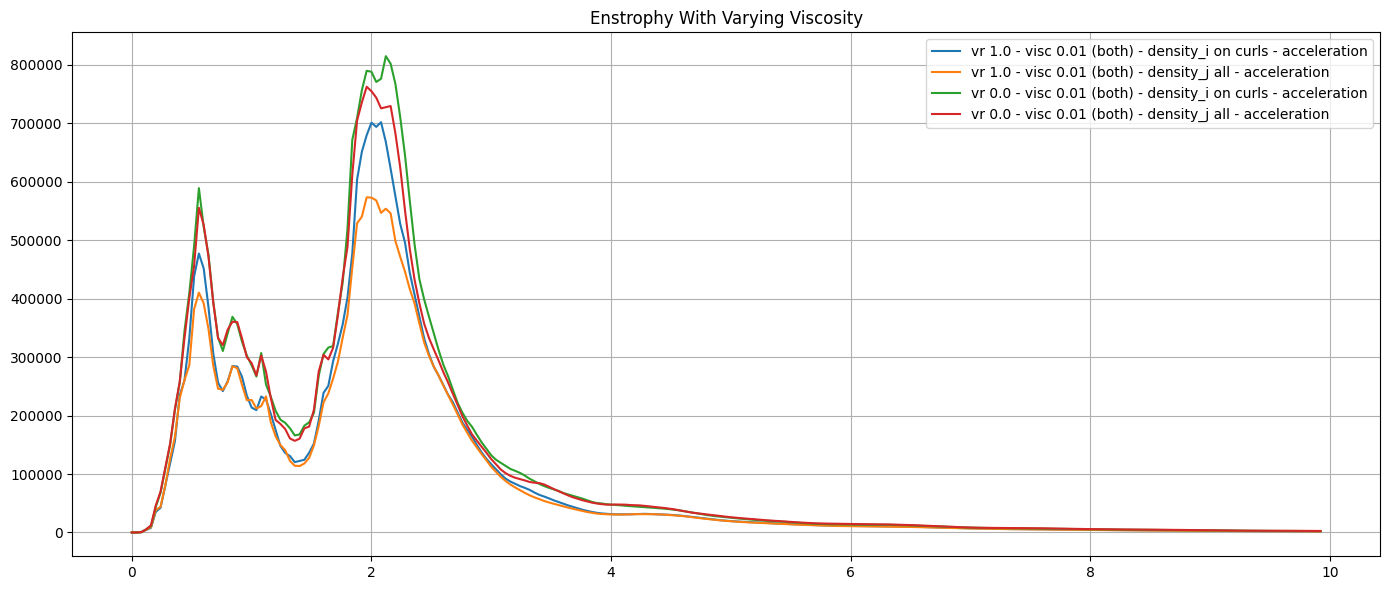

In [34]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax1.plot(time, enstrophy, label="{}".format(folder))

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Enstrophy With Varying Viscosity")

plt.tight_layout()    # neat spacing

plt.show()

## Inviscid VR Dam Break With Wall - Density i (fluid visc 0.01)

In [52]:
scene = 'DamBreakModelWithWallMoreFluid'

folder_path = splishsplash_path + '/' + scene + '/visc fluid 0.01/'

print(folder_path)

folders = os.listdir(folder_path)

folders.remove('vr 1.0 - visc 0.01 (both) - curl symmetric - acceleration')
folders.remove('vr 0.0 - visc 0.01 (both) - curl symmetric - acceleration')
# print(folders)

folders = ['vr 1.5 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'
           , 'vr 1.2 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'
           , 'vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'
           , 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration']

print(folders)

D:/gabi//DamBreakModelWithWallMoreFluid/visc fluid 0.01/
['vr 1.5 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration', 'vr 1.2 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration', 'vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration', 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration']


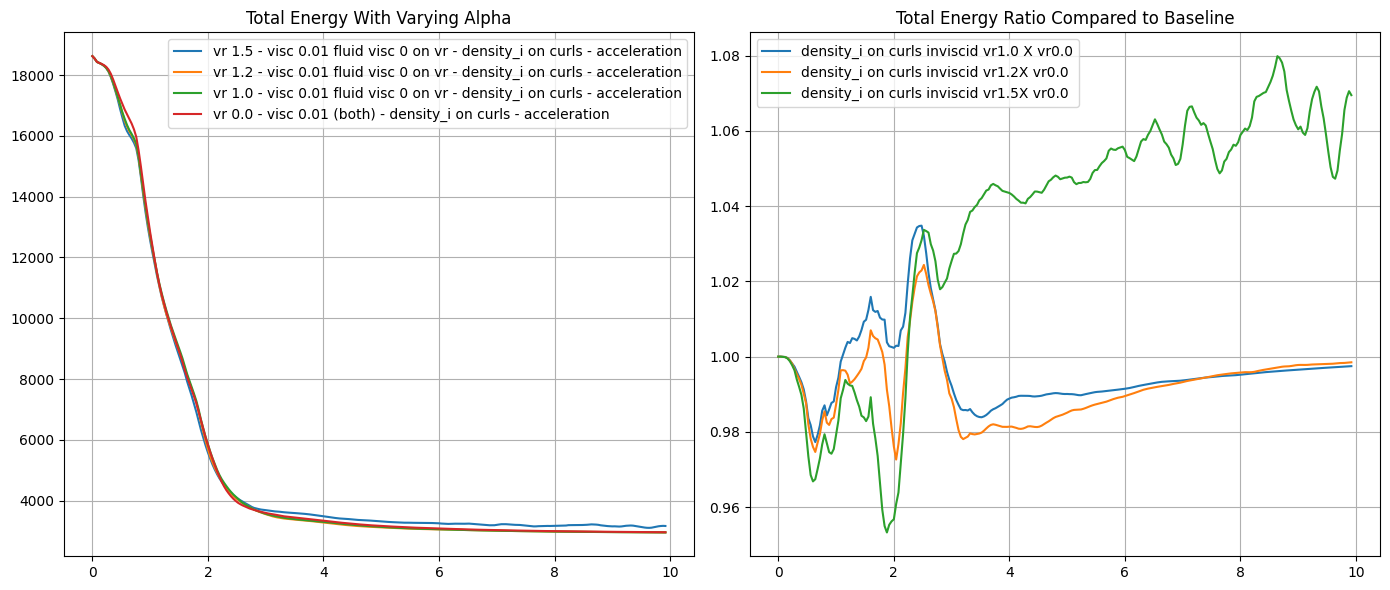

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_pot_energy + aux_kin_energy))
#             ls_total_energy.append((aux_kin_energy))
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
    ax1.plot(time, ls_total_energy, label="{}".format(folder))

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="density_i on curls inviscid vr1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.2 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="density_i on curls inviscid vr1.2X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.5 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="density_i on curls inviscid vr1.5X vr0.0")


ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


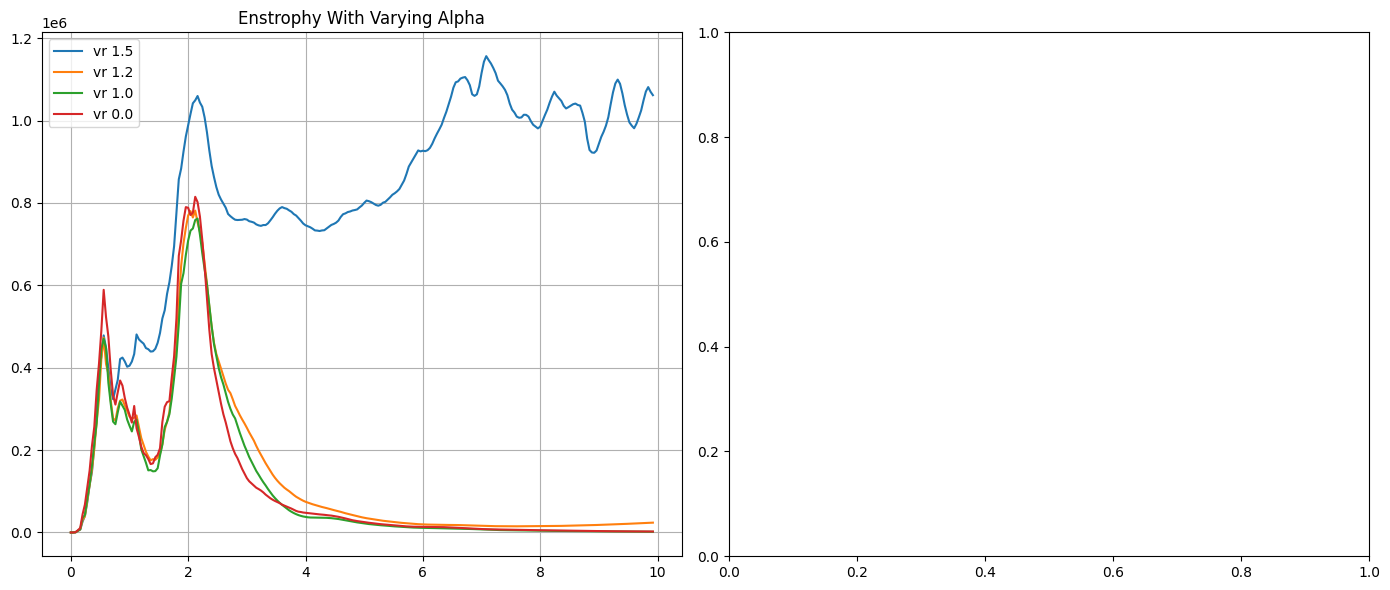

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax1.plot(time, enstrophy, label="{}".format(folder[:6]))

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Enstrophy With Varying Alpha")

plt.tight_layout()    # neat spacing

plt.show()

## Viscous VR Dam Break With Wall - Density i (fluid visc 0.01)

In [61]:
scene = 'DamBreakModelWithWallMoreFluid'

folder_path = splishsplash_path + '/' + scene + '/visc fluid 0.01/'

print(folder_path)

folders = os.listdir(folder_path)

folders.remove('vr 1.0 - visc 0.01 (both) - curl symmetric - acceleration')
folders.remove('vr 0.0 - visc 0.01 (both) - curl symmetric - acceleration')
# print(folders)

folders = ['vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration'
           , 'vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'
           , 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'
           , 'vr 1.0 - visc 0.01 fluid visc 0.03 on vr - density_i on curls - acceleration'
           ,'vr 1.0 - visc 0.01 fluid visc 0.05 on vr - density_i on curls - acceleration']

print(folders)

D:/gabi//DamBreakModelWithWallMoreFluid/visc fluid 0.01/
['vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration', 'vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration', 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration', 'vr 1.0 - visc 0.01 fluid visc 0.03 on vr - density_i on curls - acceleration', 'vr 1.0 - visc 0.01 fluid visc 0.05 on vr - density_i on curls - acceleration']


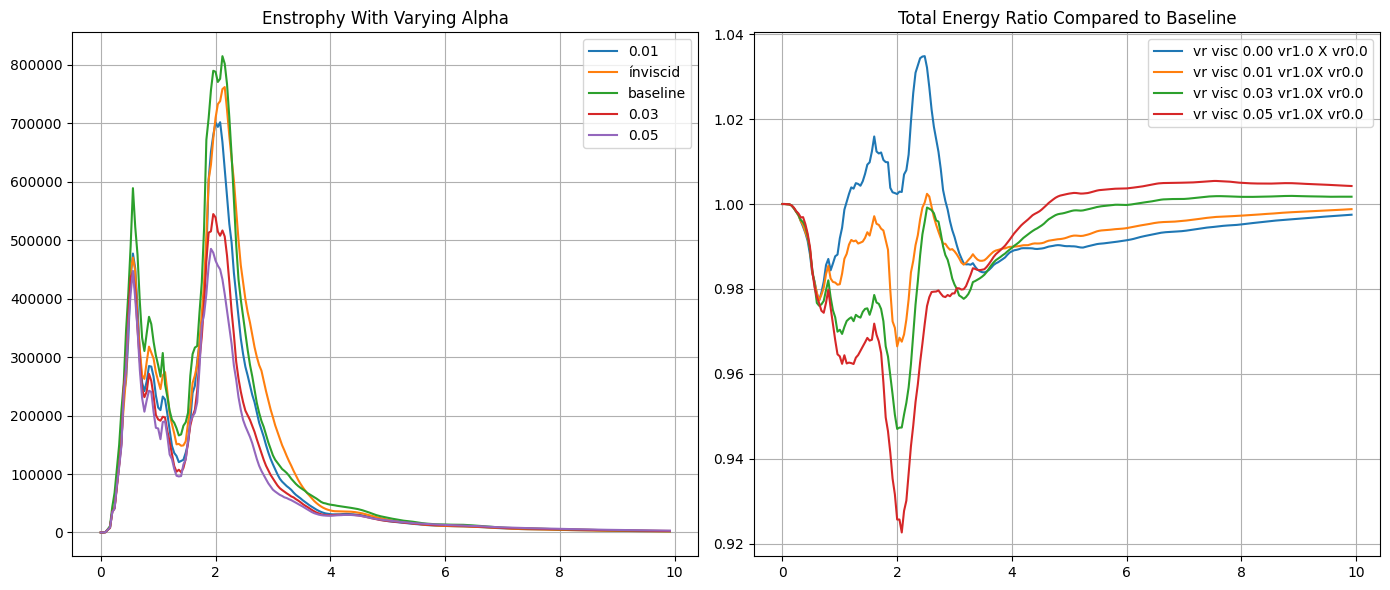

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_pot_energy + aux_kin_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))
    if folder == 'vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration':
        name = 'ínviscid'
    elif folder == 'vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration':
        name = '0.01'
    elif folder == 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration':
        name = 'baseline'
    else:
        name = folder[30:34]
    ax1.plot(time, enstrophy, label="{}".format(name))
#     ax1.plot(time[50:75], enstrophy[50:75], label="{}".format(name))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="vr visc 0.00 vr1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="vr visc 0.01 vr1.0X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 fluid visc 0.03 on vr - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="vr visc 0.03 vr1.0X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 fluid visc 0.05 on vr - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="vr visc 0.05 vr1.0X vr0.0")


ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


In [76]:
# for folder in folders:
#     print(folder)
#     if folder == 'vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration':
#         name = 'ínviscid'
#         print(name)
#     elif folder == 'vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration':
#         name = '0.01'
#         print(name)
#     elif folder == 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration':
#         name = 'baseline'
#         print(name)
#     else:
#         name = folder[30:34]
#         print(name)

vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration
0.01
vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration
ínviscid
vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration
baseline
vr 1.0 - visc 0.01 fluid visc 0.03 on vr - density_i on curls - acceleration
0.03
vr 1.0 - visc 0.01 fluid visc 0.05 on vr - density_i on curls - acceleration
0.05
